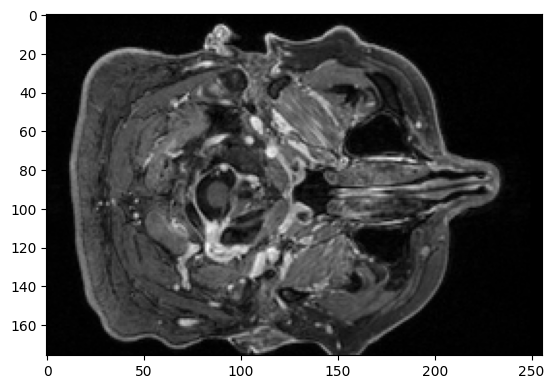

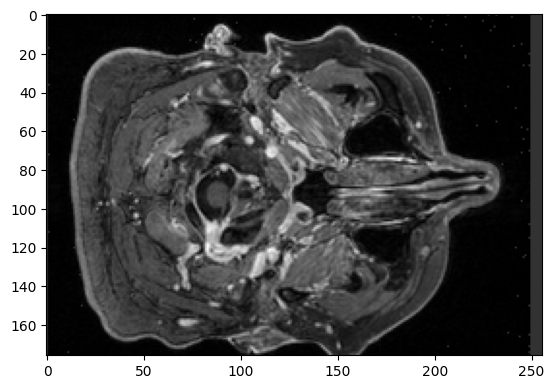

0.0


In [ ]:
import nibabel as nib
import skimage 
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, color, io
from skimage import segmentation
from skimage import morphology
from skimage.morphology import opening, closing

data = nib.load("../data/sub-KA02/anat/sub-KA02_run-02_T1w.nii.gz").get_fdata()
frame = data[:,:,89]
plt.imshow(frame,cmap='gray')
plt.show()

mascara = frame > 0
media = (frame[mascara]).mean()
desvio = (frame[mascara]).std()


frame_normalizado = (frame - media)/desvio
frame_normalizado = frame_normalizado*mascara

plt.imshow(frame_normalizado,cmap='gray')

plt.show()
print(frame_normalizado[~mascara].mean())







IMAGEN UMBRALIZADA


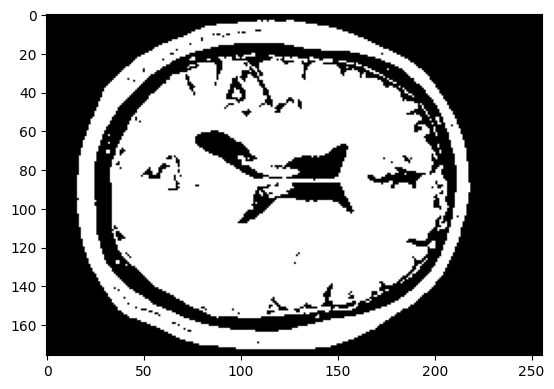

POST EROSION


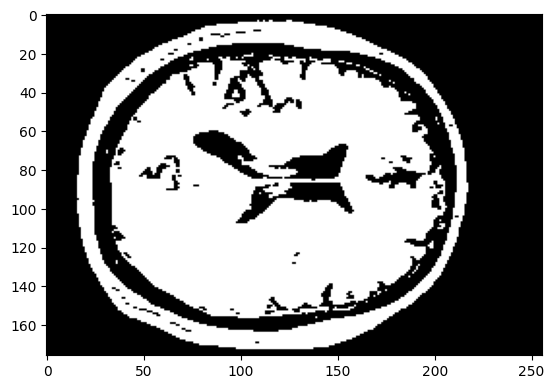

POST CLOSING


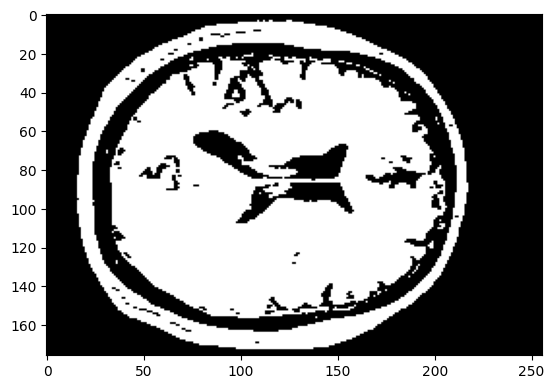

[np.float64(0.1701938150206641), np.float64(0.6363636363636364), np.float64(0.8518866938434201), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.5833333333333334), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.8571428571428571), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.8), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.7142857142857143), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.5384615384615384), np.float64(1.0)]
[False  True  True False False False False False False False False  True
 False False False  True False False False False False False False False
  True False False False  True False False False False  True False]
[0.         0.63636364 0.85188669 0.         0.         0.
 0.         0.         0. 

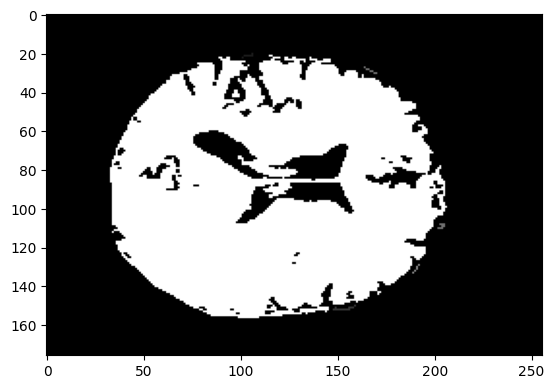

MASCARA


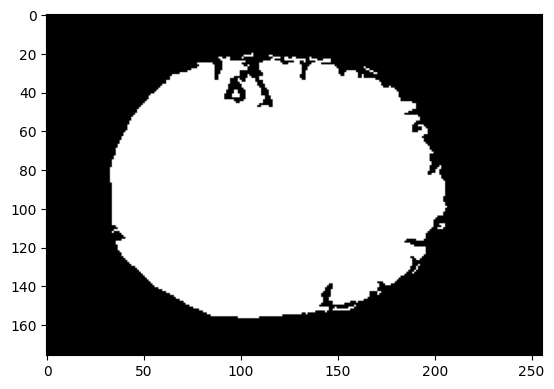

RESULTADO


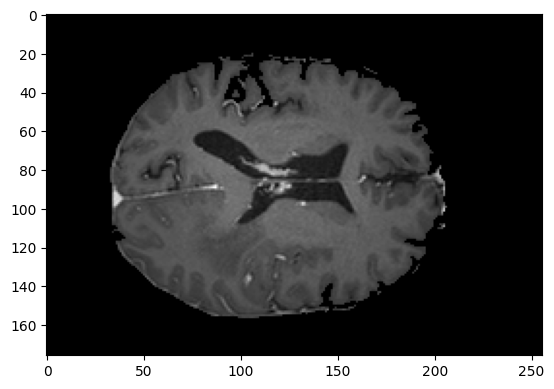

corte


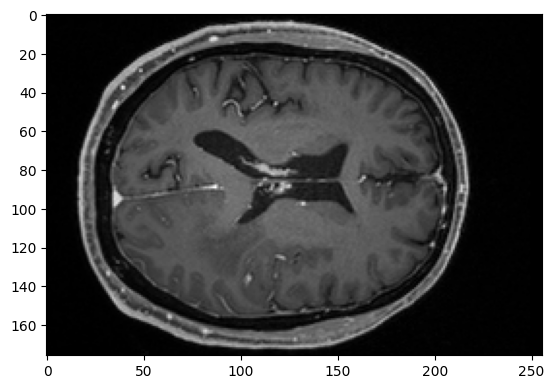

In [126]:
import nibabel as nib
import skimage 
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, color, io
from skimage import segmentation
from skimage import morphology
from skimage.morphology import opening, closing, disk, footprint_rectangle, erosion
from skimage.measure import label, regionprops
#COLSULTAR SI PODEMOS USAR ESTO
from scipy.ndimage import binary_fill_holes

data = nib.load("../data/sub-KA02/anat/sub-KA02_run-02_T1w.nii.gz").get_fdata()

class SkullStripper:
    def __init__ (self,volumen,capa):
        self.capa = capa
        self.volumen = volumen
        self.mascara = None
        self.resultado = None

    def umbral(self):
        umbral = filters.threshold_otsu(self.volumen)
        self.imagen_binaria = self.volumen > umbral
        print("IMAGEN UMBRALIZADA")
        plt.imshow(self.imagen_binaria[:,:],cmap='gray')
        plt.show()

    def aplicar_morfologia(self):
        self.imagen_binaria_erosionada = erosion(self.imagen_binaria, footprint_rectangle((1,2)))
        print("POST EROSION")
        plt.imshow(self.imagen_binaria_erosionada[:,:],cmap='gray')
        plt.show()
        self.imagen_binaria_closing = closing(self.imagen_binaria_erosionada, footprint_rectangle((1,2)))
        print("POST CLOSING")
        plt.imshow(self.imagen_binaria_closing[:,:],cmap='gray')
        plt.show()
        
    def etiquetado_y_mascara(self):
        etiquetas = label(self.imagen_binaria_closing, connectivity=2)
        propiedades = regionprops(etiquetas)
        #areas = [region.area for region in propiedades]
        #print("Cantidad de componentes:", len(areas))
        #print("Area de la componente mayor:", max(areas))
        #indice = np.argmax(areas)
        solidez = [region.solidity for region in propiedades]
        print(solidez)
        eliminar = (solidez != max(solidez)) & (solidez != min(solidez))
        print(eliminar)
        solidez = solidez*eliminar
        print(solidez)
        indice = np.argmax(solidez)
        mascara = 0
        n = 0
        for i in range(len(solidez)):
            if solidez[i] != min(solidez):
                n = etiquetas == (i+1)
            mascara = mascara + n
        print("MASCARA ANTES DE FILL HOLES")
        plt.imshow(mascara[:,:], cmap='gray')
        plt.show()
        mascara_rellena = binary_fill_holes(mascara)
        self.resultado = self.volumen * mascara_rellena
        print("MASCARA")
        plt.imshow(mascara_rellena[:,:],cmap='gray')
        plt.show()
        
        self.resultado = self.volumen * mascara_rellena
        print("RESULTADO")
        plt.imshow(self.resultado[:,:],cmap='gray')
        plt.show()
        print("corte")
        plt.imshow(self.volumen[:,:],cmap='gray')
        plt.show()

    def strip(self):
        self.umbral()
        self.aplicar_morfologia()
        self.etiquetado_y_mascara()
        return self.resultado

volumen = data[:,:,170]
stripper = SkullStripper(volumen,170)
resultado = stripper.strip()

